In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Open camera (0 = default webcam)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Cannot open camera")
    exit()

ret, frame = cap.read()

if ret:
    cv2.imshow("First Frame", frame)

    cv2.imwrite("first_frame.jpg", frame)
    print("First frame saved as first_frame.jpg")
else:
    print("Error: Could not read frame")

cv2.waitKey(0)

cap.release()
cv2.destroyAllWindows()

First frame saved as first_frame.jpg


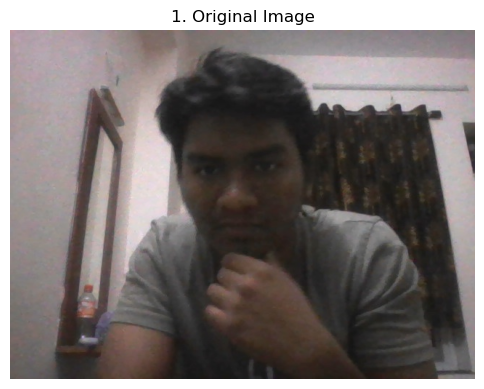

In [5]:
img = cv2.imread("first_frame.jpg")

# Convert BGR to RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("1. Original Image")
plt.axis("off")
plt.show()


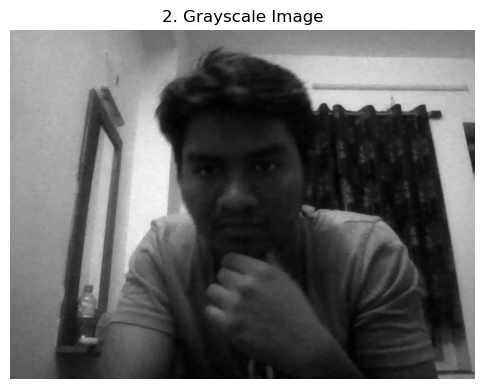

In [6]:

# 2️⃣ Convert to Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,6))
plt.imshow(gray, cmap="gray")
plt.title("2. Grayscale Image")
plt.axis("off")
plt.show()

# 3️⃣ Gaussian Blur (Noise Reduction)


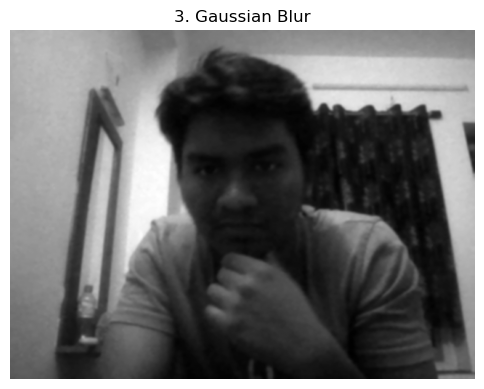

In [7]:
blur = cv2.GaussianBlur(gray, (5,5), 1.4)

plt.figure(figsize=(6,6))
plt.imshow(blur, cmap="gray")
plt.title("3. Gaussian Blur")
plt.axis("off")
plt.show()

# 4️⃣ Gradient Calculation (Sobel)


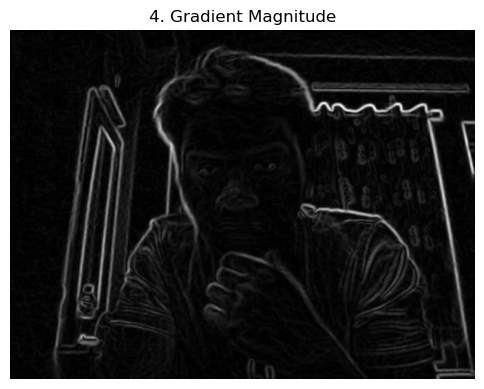

In [9]:
gx = cv2.Sobel(blur, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(blur, cv2.CV_64F, 0, 1, ksize=3)

magnitude = np.sqrt(gx**2 + gy**2)
magnitude = magnitude / magnitude.max() * 255

plt.figure(figsize=(6,6))
plt.imshow(magnitude, cmap="gray")
plt.title("4. Gradient Magnitude")
plt.axis("off")
plt.show()



# 5️⃣ Gradient Direction

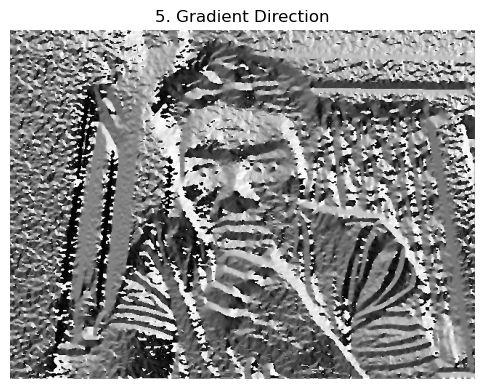

In [10]:
direction = np.arctan2(gy, gx)

plt.figure(figsize=(6,6))
plt.imshow(direction, cmap="gray")
plt.title("5. Gradient Direction")
plt.axis("off")
plt.show()

# 6️⃣ Non-Maximum Suppression


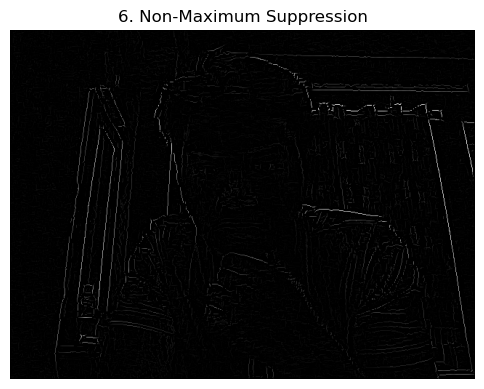

In [11]:
h, w = magnitude.shape
nms = np.zeros((h,w), dtype=np.int32)

angle = direction * 180. / np.pi
angle[angle < 0] += 180

for i in range(1, h-1):
    for j in range(1, w-1):

        q = 255
        r = 255

        if (0 <= angle[i,j] < 22.5) or (157.5 <= angle[i,j] <= 180):
            q = magnitude[i, j+1]
            r = magnitude[i, j-1]

        elif (22.5 <= angle[i,j] < 67.5):
            q = magnitude[i+1, j-1]
            r = magnitude[i-1, j+1]

        elif (67.5 <= angle[i,j] < 112.5):
            q = magnitude[i+1, j]
            r = magnitude[i-1, j]

        elif (112.5 <= angle[i,j] < 157.5):
            q = magnitude[i-1, j-1]
            r = magnitude[i+1, j+1]

        if (magnitude[i,j] >= q) and (magnitude[i,j] >= r):
            nms[i,j] = magnitude[i,j]
        else:
            nms[i,j] = 0

plt.figure(figsize=(6,6))
plt.imshow(nms, cmap="gray")
plt.title("6. Non-Maximum Suppression")
plt.axis("off")
plt.show()

# 7️⃣ Double Threshold


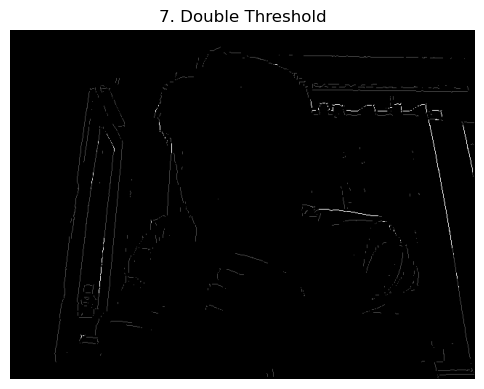

In [12]:
low = 50
high = 150

strong = 255
weak = 75

res = np.zeros((h,w), dtype=np.int32)

strong_i, strong_j = np.where(nms >= high)
weak_i, weak_j = np.where((nms <= high) & (nms >= low))

res[strong_i, strong_j] = strong
res[weak_i, weak_j] = weak

plt.figure(figsize=(6,6))
plt.imshow(res, cmap="gray")
plt.title("7. Double Threshold")
plt.axis("off")
plt.show()

# 8️⃣ Edge Tracking by Hysteresis


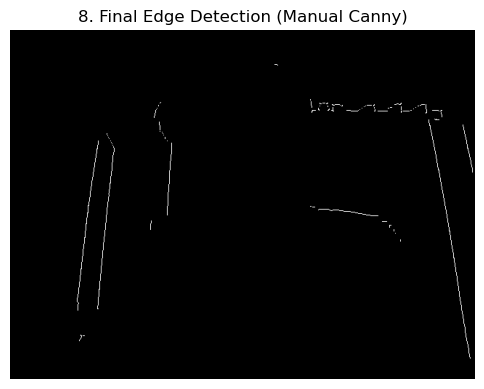

In [13]:
for i in range(1, h-1):
    for j in range(1, w-1):
        if res[i,j] == weak:
            if ((res[i+1, j-1] == strong) or (res[i+1, j] == strong) or (res[i+1, j+1] == strong)
                or (res[i, j-1] == strong) or (res[i, j+1] == strong)
                or (res[i-1, j-1] == strong) or (res[i-1, j] == strong) or (res[i-1, j+1] == strong)):
                res[i,j] = strong
            else:
                res[i,j] = 0

plt.figure(figsize=(6,6))
plt.imshow(res, cmap="gray")
plt.title("8. Final Edge Detection (Manual Canny)")
plt.axis("off")
plt.show()

# Using Canny

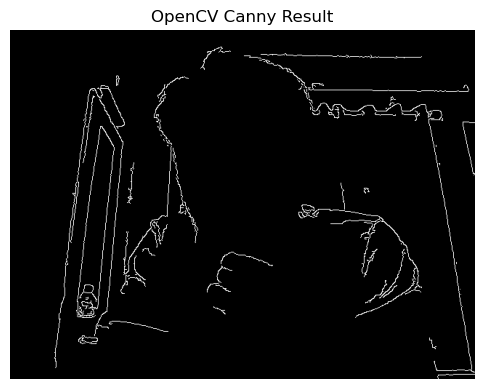

In [14]:
edges = cv2.Canny(gray, 50, 150)

plt.figure(figsize=(6,6))
plt.imshow(edges, cmap="gray")
plt.title("OpenCV Canny Result")
plt.axis("off")
plt.show()